## Car Price Prediction

### 🎯 Goal:
Build a regression model to predict car prices based on features like horsepower and mileage.

### 🪜 Steps:
1. Load and explore the dataset
2. Handle missing values
3. Perform data visualization (EDA)
4. Split data into training and testing sets
5. Apply feature scaling
6. Train a Linear Regression model
7. Evaluate the model performance
8. Visualize predictions vs actual values

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

## Load Data

In [2]:
data3 = pd.read_csv(r"D:\Downloads\archive (3)\car data.csv")
data3.columns = data3.columns.str.strip() #Clean column names

## Explore Data

In [3]:
print(data3.head())
print(data3.info())
print(data3.describe())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  3

## Handle Missing Values

In [4]:
data3 = data3.dropna()

## Feature Engineering 

In [5]:
data3['Age'] = 2026 - data3['Year']

## EDA

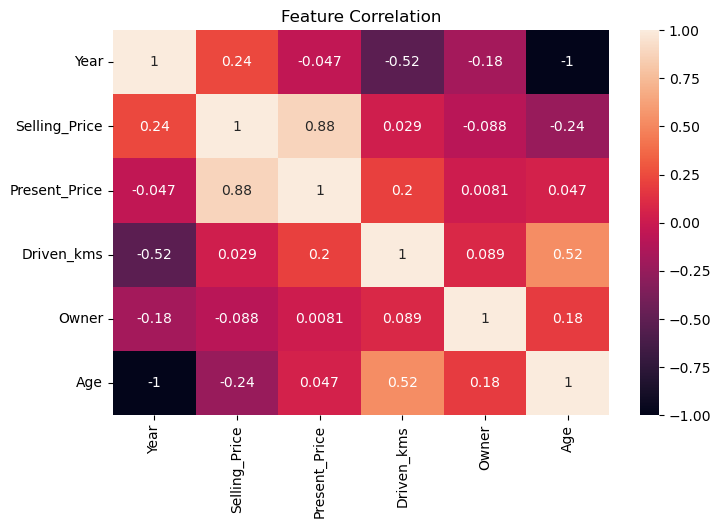

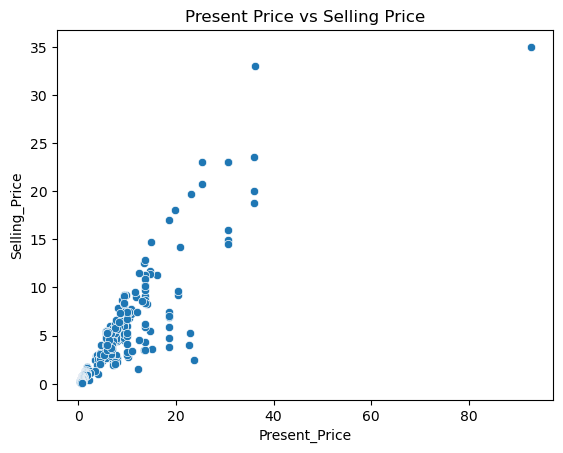

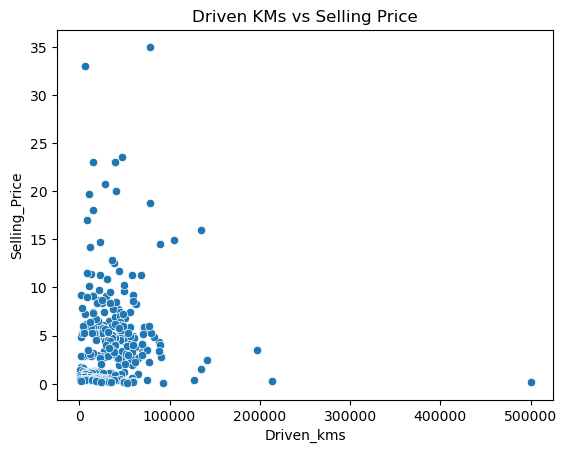

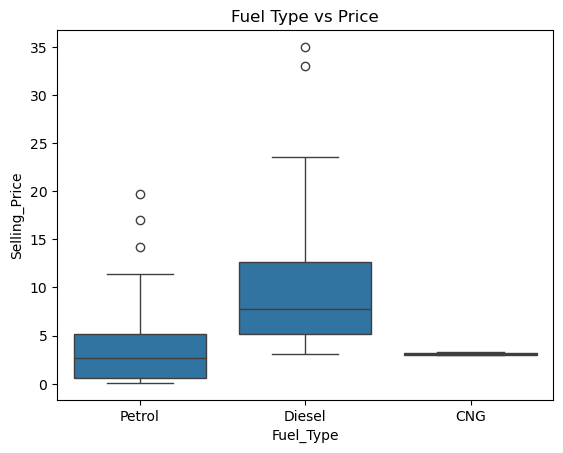

In [6]:
# Correlation Heatmap
plt.figure(figsize=(8,5))
sns.heatmap(data3.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation")
plt.show()

# Scatter: Present Price vs Selling Price
plt.figure()
sns.scatterplot(x=data3['Present_Price'], y=data3['Selling_Price'])
plt.title("Present Price vs Selling Price")
plt.show()

# Scatter: Driven KMs vs Selling Price
plt.figure()
sns.scatterplot(x=data3['Driven_kms'], y=data3['Selling_Price'])
plt.title("Driven KMs vs Selling Price")
plt.show()

# Boxplot: Fuel Type vs Price
plt.figure()
sns.boxplot(x=data3['Fuel_Type'], y=data3['Selling_Price'])
plt.title("Fuel Type vs Price")
plt.show()

## Features

In [7]:
X = data3[['Present_Price', 'Driven_kms', 'Owner', 'Age']]
y = data3['Selling_Price']

## Split & Scaling

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Prediction

In [10]:
y_pred = model.predict(X_test)

## Evaluation

In [11]:
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.3943701771121797
R2 Score: 0.820905113512261


## Visualization

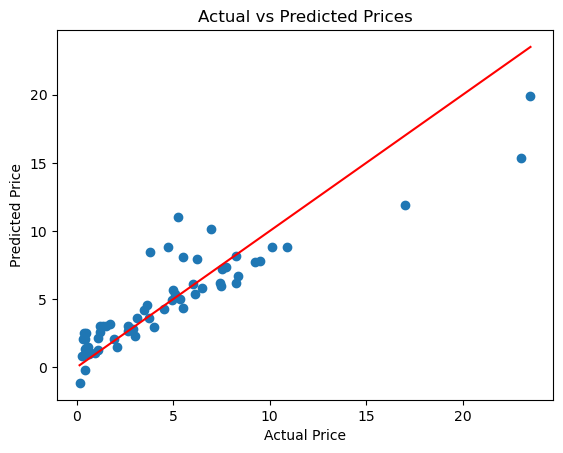

In [12]:
plt.figure()

plt.scatter(y_test, y_pred)

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

### 🧠 Insights:

- Present Price has the strongest positive impact on Selling Price.
- Older cars (higher Age) tend to have lower selling prices.
- Cars with higher driven kilometers are generally cheaper.
- Fuel type affects price variation across different cars.
- The model shows a good correlation between actual and predicted values.